In [1]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
devtools::load_all("utils/modules/R/gwastools")
library(data.table)
library(pROC)
library(reshape2)
library(bigstatsr)
library(ggplot2)
library(ggrastr)
library(ggrepel)
library(ggforce)

i Loading gwastools

Loading required package: data.table

Loading required package: ggplot2

Loading required package: stringr

Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var



Attaching package: 'reshape2'


The following objects are masked from 'package:data.table':

    dcast, melt




In [2]:
dir = "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/prs/validation"

In [3]:
args <- list(
    summary_ldsc = "data/prs/validation/ldsc_summary.txt.gz",
    summary_prs_cts = "data/prs/validation/pgs_cor_summary.txt.gz",
    summary_prs_bin = "data/prs/validation/pgs_auc_summary.txt.gz",
    bin_header = 'data/phenotypes/filtered_phenotypes_binary_header.tsv',
    cts_header = 'data/phenotypes/filtered_phenotypes_cts_manual.tsv'
)

In [4]:
ldsc <- fread(args$summary_ldsc)
cts <- fread(args$summary_prs_cts)
bin <- fread(args$summary_prs_bin)

In [5]:
binary_header <- readLines(args$bin_header)
binary_header <- binary_header[!grepl("primary_care", binary_header)]
cts_header <- paste0(readLines(args$cts_header),"_int")

In [6]:
colnames(ldsc) <- paste0("ldsc_",colnames(ldsc))
#table(ldsc$ldsc_phenotype)

In [7]:
colnames(ldsc)[colnames(ldsc) == "ldsc_phenotype"] <- "phenotype"

In [8]:
# why is this only 37? These all have very low case count. I think we might have exluded them.
length(unique(ldsc[ldsc$phenotype %in% binary_header]$phenotype))
binary_header[!binary_header %in% ldsc[ldsc$phenotype %in% binary_header]$phenotype]

[1] 32

[1] "ADHD_combined" "OLI_combined"  "EP_combined"   "HAB_combined" 
[5] "POI_combined"

In [9]:
res_bin <- merge(ldsc, bin, all.x = TRUE)
res_bin <- res_bin[res_bin$phenotype %in% binary_header,]
res_cts <- merge(ldsc, cts, all.x = TRUE)
res_cts <- res_cts[res_cts$phenotype %in% cts_header,]

In [10]:
res_subset_bin <- res_bin[res_bin$ldsc_coef == "h2",]
res_subset_bin$pass_qc <- res_subset_bin$ldsc_pvalue < 1e-5
res_subset_bin_phenos_pass <- res_subset_bin$phenotype[res_subset_bin$pass_qc]
res_subset_bin_phenos_pass <- as.character(res_subset_bin_phenos_pass)

In [11]:
res_bin$included <- ifelse(res_bin$phenotype %in% res_subset_bin_phenos_pass, 'Yes', "No")

In [12]:
# rename phenotypes
res_bin$phenotype <- gsub("_combined","", res_bin$phenotype)

In [13]:
# setup color scale
my_colors <- c("grey","#65B8EF") #"#4DBBD5B2")
names(my_colors) <- c("No","Yes")

fill_scale <- scale_fill_manual(name = "Used downstream", values = my_colors)
color_scale <- scale_color_manual(name = "Used downstream", values = my_colors)

In [14]:
res_order <- res_bin[res_bin$ldsc_coef == "h2"]
levels <- res_order$phenotype[order(res_order$ldsc_pvalue)]
res_bin$phenotype <- factor(res_bin$phenotype, levels = levels)

In [15]:
options(repr.matrix.max.rows=100, repr.matrix.max.cols=30)
#res_bin
length(unique(res_bin$phenotype))

[1] 32

In [16]:
point_size = 0.75

p1 <- ggplot(res_bin[res_bin$ldsc_coef == "h2",], 
       aes(
           y=phenotype, #reorder(phenotype, ldsc_estimate),
           x=ldsc_estimate, 
           xmax=ldsc_estimate+ldsc_std_error,
           xmin=ldsc_estimate-ldsc_std_error,
           color=included
           )
      ) + 
    geom_pointrange(size = point_size) +
    xlab(expression("LDSC" ~h^2)) + 
    ylab("Phenotypes") +
    theme_bw() +
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    coord_cartesian(xlim=c(0, 1)) +
    color_scale +
    theme(
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.position="none"
    ) + guides(color="none")

p2 <- ggplot(res_bin[res_bin$ldsc_coef == "intercept",], 
       aes(
           y=phenotype,
           x=ldsc_estimate, 
           xmax=ldsc_estimate+ldsc_std_error,
           xmin=ldsc_estimate-ldsc_std_error,
           color=included
           )
      ) + 
    theme_bw() +
    geom_pointrange(size = point_size) +
    xlab(expression("LDSC intercept")) + 
    geom_vline(xintercept = 1, linetype = 'dashed') +
    scale_x_continuous(breaks=scales::pretty_breaks(n=3)) + 
    color_scale +
    theme(axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank(),
        strip.text = element_text(size=16),
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.position="none"
    ) + guides(color="none")

p3 <- ggplot(res_bin[res_bin$ldsc_coef == "h2",], 
       aes(
           y=phenotype, #y=reorder(phenotype, ldsc_estimate),
           x=-log10(ldsc_pvalue),
           xmax=-log10(ldsc_pvalue),
           xmin=-log10(ldsc_pvalue),
           color=included
           )
      ) + 
    geom_pointrange(size = point_size) +
    xlab(expression("LDSC"~log[10]*"(P-value)")) +
    geom_vline(xintercept = -log10(1e-5), linetype = 'dashed') +
    theme_bw() +
    color_scale +
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    theme(axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank(),
        strip.text = element_text(size=16),
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.position="none"
    ) + guides(color="none")

p4 <- ggplot(res_bin, 
       aes(
           y=phenotype, #y=reorder(phenotype, ldsc_estimate),
           x=auc_mean,
           xmax=auc_2_5_pct,
           xmin=auc_97_5_pct,
           color=included
           )
      ) + 
    geom_pointrange(size = point_size) +
    theme_bw() +
    color_scale +
    geom_vline(xintercept = 0.5, linetype = 'dashed') +
    xlab(expression("AUROC (95% CI)")) + 
    ylab("Phenotypes") +
    scale_x_continuous(breaks=scales::pretty_breaks(n=4)) +
    theme(axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank(),
        strip.text = element_text(size=16),
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.position="none"
    ) + guides(color="none")

Warning message:
"Removed 6 rows containing missing values (geom_pointrange)."
Warning message:
"Removed 6 rows containing missing values (geom_pointrange)."


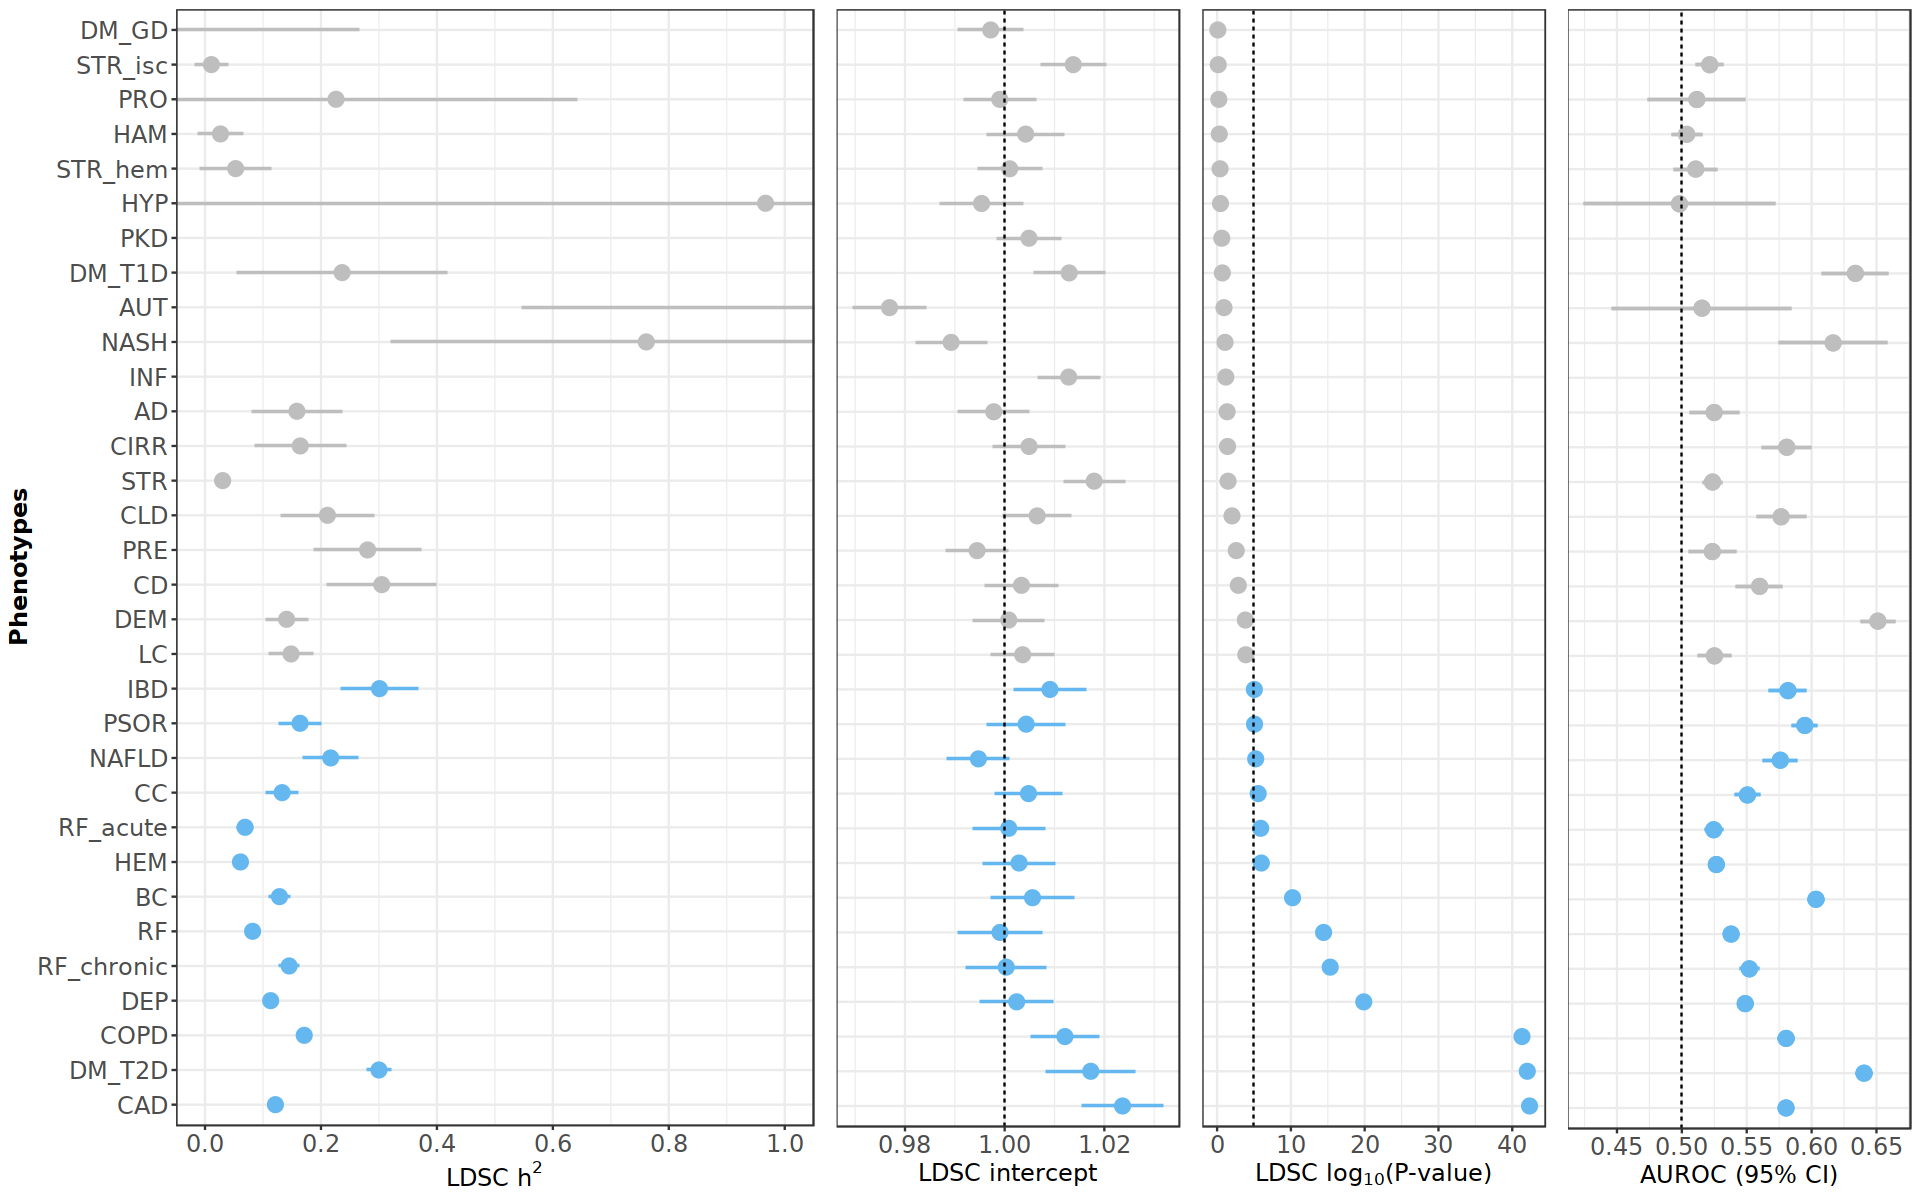

In [17]:
ggsave("derived/plots/220908_ldpred_ldsc_summary_combined.pdf", width = 13, height = 8)
options(repr.plot.width=16, repr.plot.height=10)
cowplot::plot_grid(p1, p2, p3, p4, rel_widths = (c(0.45, 0.2, 0.2, 0.2)), ncol = 4, nrow = 1)

In [18]:
# Note, that PKD_combined is not shown because the estimate goes beyond the borders.

# PRS qq-plots

In [19]:
get_qq_df <- function(files){
    ribbon_p <- 0.95
    d <- do.call(rbind, lapply(files, function(f){
        stopifnot(file.exists(f))
        d <- fread(f)
        if (nrow(d) > 0){
            # read from conditional analysis if present
            if ("p.value_c" %in% colnames(d)) {
                d$p.value <- d$p.value_c
            }
            d$p.value.expt <- get_expected_p(d$p.value, na.rm = TRUE)
            n <- length(d$p.value)
            # create QQ
            dt <- data.table(
                ensembl_gene_id = d$MarkerID[order(d$p.value)],
                pvalue = sort(d$p.value),
                pvalue.observed = -log10(sort(d$p.value)),
                pvalue.expected = -log10(sort(d$p.value.expt)),
                clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
                cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n))
            )
            # regex the current phenotype and clean
            dt$prs <- ifelse(grepl("locoprs", f),"With PRS", "Without PRS")
            dt$analysis <- str_extract(basename(f), 'maf0to5e-2_.+_pLoF')
            dt$analysis <- gsub("maf0to5e-2_", "", dt$analysis)
            dt$analysis <- gsub("_pLoF", "", dt$analysis)
            dt$analysis <- gsub("_combined", "", dt$analysis)
                       
            # add hgnc and grch38 position
            dt$hgnc_symbol <- ensembl_to_hgnc[dt$ensembl_gene_id]
            dt$contig <- ensembl_to_contig[dt$ensembl_gene_id]
            dt$pos <- ensembl_to_pos[dt$ensembl_gene_id]
            
            # plot label if deviated from null
            dt$label <- NA 
            bool <- dt$pvalue.observed >= dt$clower & dt$pvalue.observed > 3
            dt$label[bool] <- dt$hgnc_symbol[bool]
            
 
        return(dt)
        } else {
            return(NULL)
        }
    }))
    return(d)
}

In [20]:
# map from ENSEMBL to HGNC
bridge <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/220524_hgnc_ensg_enst_chr_pos.txt.gz")
ensembl_to_hgnc <- bridge$hgnc_symbol
names(ensembl_to_hgnc) <- bridge$ensembl_gene_id
ensembl_to_pos <- (bridge$start_position + bridge$end_position)/2
names(ensembl_to_pos) <- bridge$ensembl_gene_id
ensembl_to_contig <- bridge$chromosome_name
names(ensembl_to_contig) <- bridge$ensembl_gene_id

In [21]:
pattern <- "ukb_eur_wes_200k_maf0to5e-2.+txt.gz"
files <- list.files("data/saige/output/binary/step2/min_mac4/", pattern = pattern, full.names = TRUE)
files <- files[!grepl("primary_care",files)]

In [22]:
files_prs <- files[grepl("locoprs",files)]

In [23]:
files_no_prs <- files[!grepl("locoprs",files)]

In [24]:
d <- get_qq_df(files)

In [25]:
d$prs <- factor(d$prs)

In [26]:
# setup color scale
my_colors <- c("#CC6666","#65B8EF") #c("#7BA98A","#65B8EF")
names(my_colors) <- c("Without PRS", "With PRS")
fill_scale <- scale_fill_manual(name = "PRS", values = my_colors)
color_scale <- scale_color_manual(name = "PRS", values = my_colors)

In [45]:
phenotypes_to_plot <- c("IBD","CD","NALFD","OLI","PSOR",
                        "RF","LC","CC", "AD", "BC", 
                        "CAD", "DEP","HAB","ADHD","DM_T1D", 
                        "DM_GD", "DM_T2D","COPD","CIRR","HEM","CLD")
d_plot <- d[d$analysis %in% phenotypes_to_plot,]
d_plot_no_prs <- d_plot[d_plot$prs == "Without PRS",]

Warning message:
"Ignoring unknown parameters: label.padding"
Warning message:
"Removed 47856 rows containing missing values (geom_text_repel)."


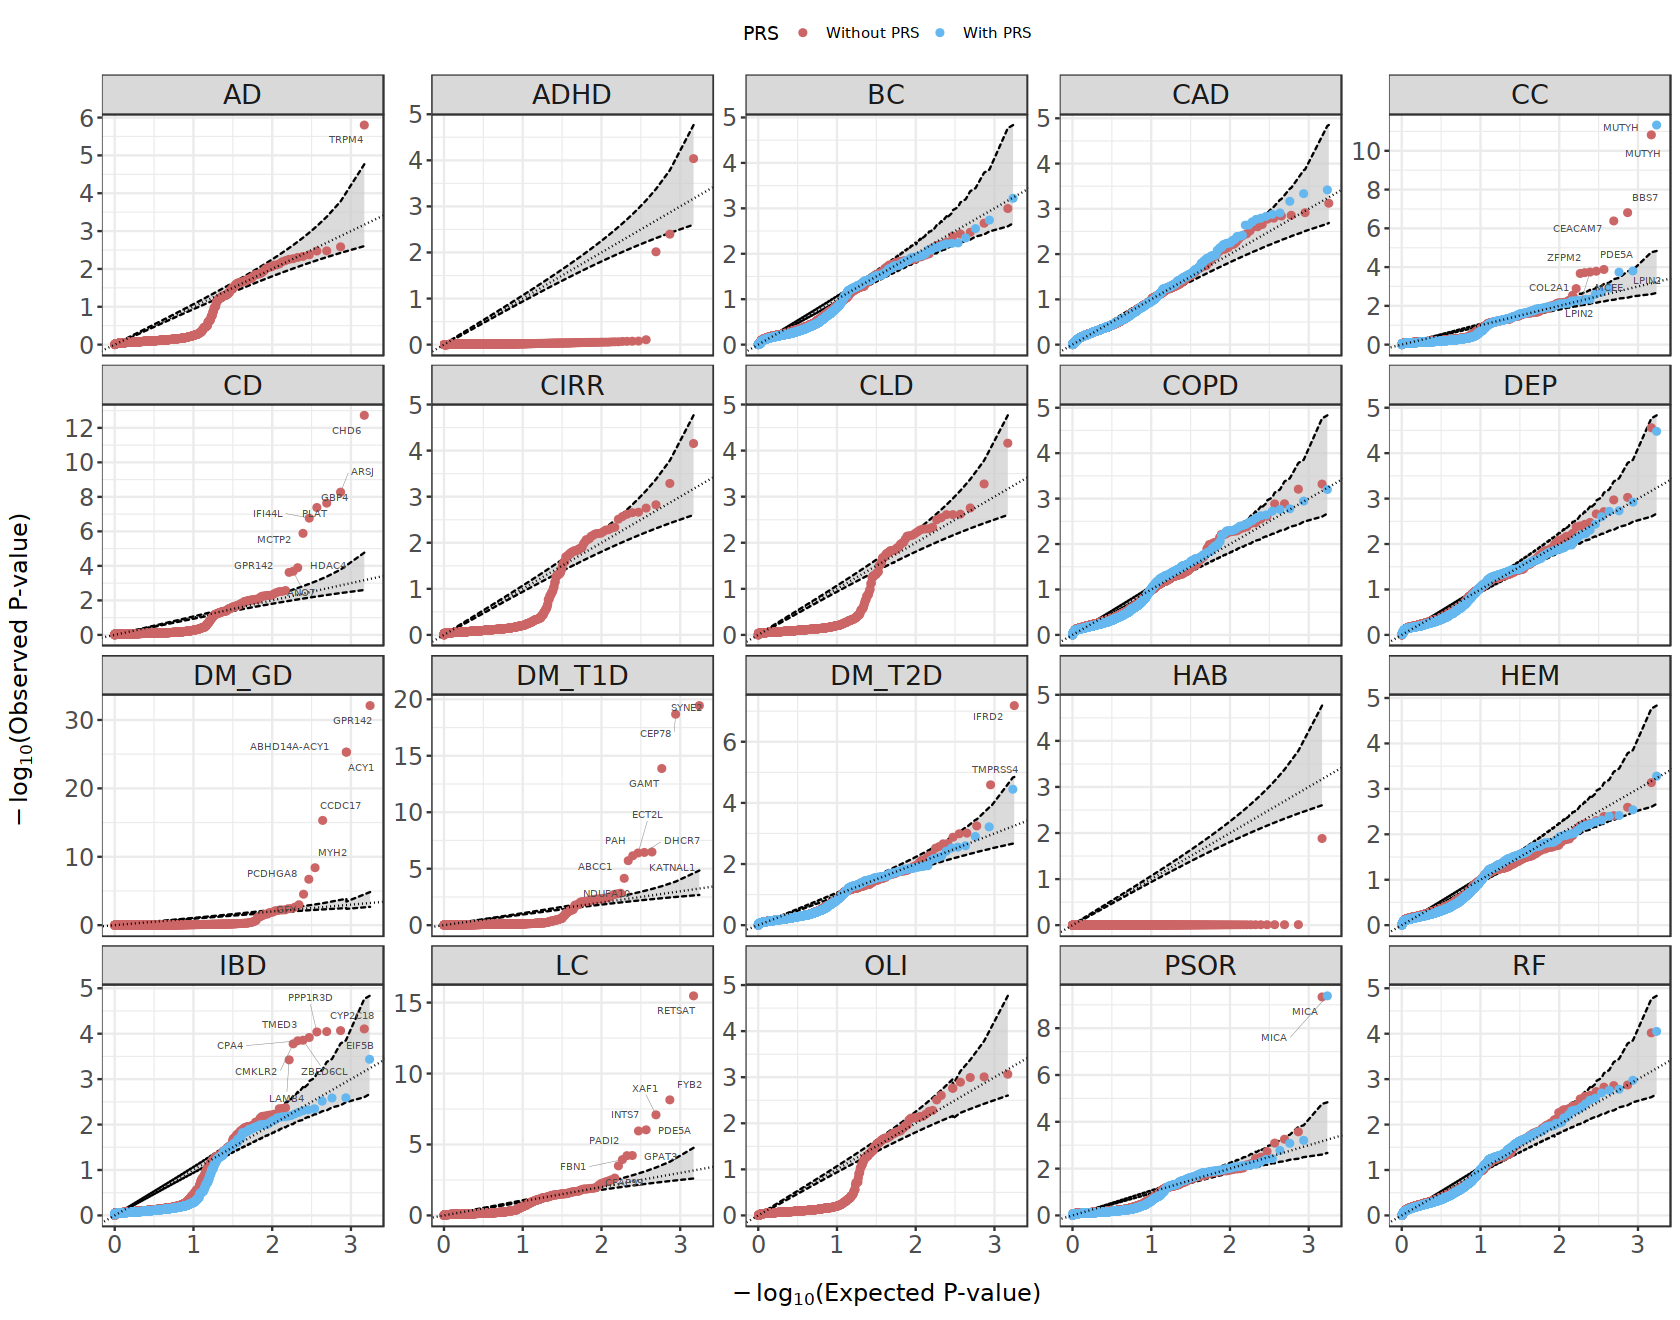

In [48]:
options(repr.plot.width=14, repr.plot.height=11)
ggplot(d_plot, aes(x=pvalue.expected, y=pvalue.observed, ymax=cupper, ymin=clower, label = label, color = prs)) +
    geom_ribbon(fill="grey80", color="black", alpha = 0.7, linetype = 'dashed') +
    geom_point() +
    geom_abline(linetype = 'dotted') + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    color_scale +
    geom_text_repel(
        box.padding = 0.4, label.padding=0.1, point.padding = 0.2,
        color = 'grey30', segment.color = 'grey50', max.overlaps=Inf,
        size=2, segment.size=0.1, show.legend = FALSE
    ) +
    facet_wrap_paginate(~analysis, nrow = 4, ncol = 5, page = 1, scales = "free_y") +
    theme_bw() +
    theme(
        strip.text = element_text(size=16),
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.position="top"
    )